<a href="https://colab.research.google.com/github/Almat-nag/deep-learning-final-project/blob/master/notebooks/week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Week 1: Dataset Selection and Basic EDA
# Project: Toxic Comment Classification

!pip install datasets -q

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load dataset
dataset = load_dataset("m375zhan/modified_jigsaw_toxic_comment_classification_challenge")

print(dataset)

df = dataset["train"].to_pandas()

print("Dataset shape:", df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/527 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/43.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
})
Dataset shape: (159571, 8)


,id,text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [2]:
# Dataset columns

print("Columns:")
print(df.columns)

Columns:
Index(['id', 'text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult',
       'identity_hate'],
      dtype='object')


In [3]:
# Target labels

target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

In [4]:
# Missing values check

print("Missing values:")
print(df[["text"] + target_columns].isnull().sum())

Missing values:
text             0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


In [5]:
# Label distribution

label_counts = df[target_columns].sum().sort_values(ascending=False)

print("Label distribution:")
print(label_counts)

Label distribution:
toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


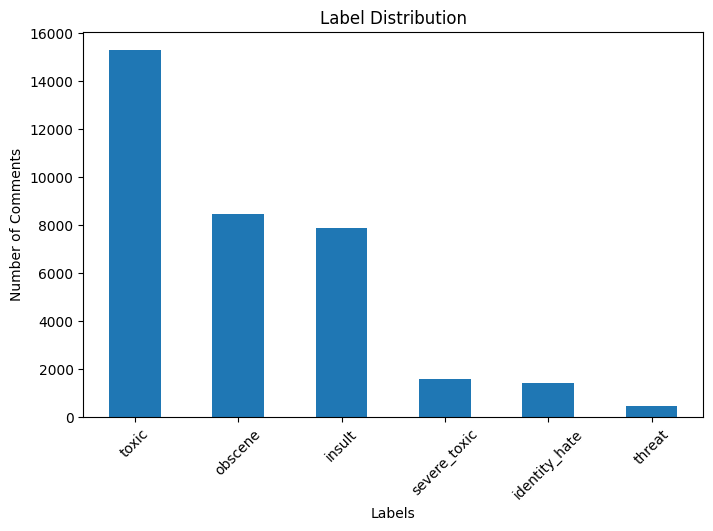

In [6]:
# Label distribution graph

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")

plt.title("Label Distribution")
plt.xlabel("Labels")
plt.ylabel("Number of Comments")
plt.xticks(rotation=45)
plt.show()

In [7]:
# Basic text length analysis

df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

print("Text length statistics:")
print(df["text_length"].describe())

Text length statistics:
count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
25%          17.000000
50%          36.000000
75%          75.000000
max        1411.000000
Name: text_length, dtype: float64


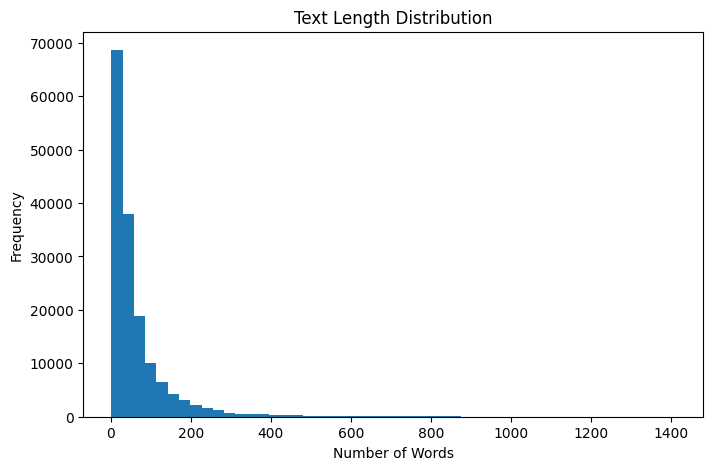

In [8]:
# Text length graph

plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()